In [26]:
#TASK 1 — Dataset Understanding

#1.1 Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\customer_churn_nn.csv")
df.head()

#1.2 Basic Exploration
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
print("\nTarget Distribution:\n", df['churn'].value_counts())
print("\nTarget Distribution (%):\n", df['churn'].value_counts(normalize=True) * 100)
print("\nStatistical Summary:\n", df.describe())


Shape: (2000, 17)

Data Types:
 customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per

In [17]:
#TASK 2 — Data Preprocessing

#2.1 Clean & Prepare Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_model = df.copy()

# Drop ID column
df_model = df_model.drop(columns=['customer_id'])

# Separate target
y = df_model['churn']
X = df_model.drop(columns=['churn'])

# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_features, categorical_features

#2.2 Handle Missing Values
# Numeric → median
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())

# Categorical → mode
if categorical_features:
    X[categorical_features] = X[categorical_features].fillna(X[categorical_features].mode().iloc[0])

#2.3 One‑Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

#2.4 Train–Test Split + Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)



Train: (1600, 24) Test: (400, 24)


TASK 3 — Neural Network Model Building

3.1 How Neural Networks Learn (Forward Pass → Loss → Backprop → Updates)

Forward Pass
Inputs are multiplied by weights

Bias is added

Activation functions transform the output

Final output = churn probability

Loss Calculation
Binary cross‑entropy measures prediction error.

Backpropagation
Gradients show how much each weight contributed to the error.

Parameter Updates
Weights updated using gradient descent.

In [18]:
#3.2 Build the Neural Network Architecture

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

input_dim = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


#3.3 Demonstration of Learning Mechanics

import tensorflow as tf

# Take a small batch from training data
X_batch = tf.convert_to_tensor(X_train_scaled[:5], dtype=tf.float32)

# FIX: reshape y_batch to match model output shape (5,1)
y_batch = tf.convert_to_tensor(y_train[:5].values.reshape(-1, 1), dtype=tf.float32)

# Use GradientTape to track operations
with tf.GradientTape() as tape:
    # Forward pass
    y_pred = model(X_batch, training=True)
    
    # Loss calculation
    loss = tf.keras.losses.binary_crossentropy(y_batch, y_pred)

# Backpropagation: compute gradients
gradients = tape.gradient(loss, model.trainable_variables)

# One manual update step
optimizer = tf.keras.optimizers.Adam()
optimizer.apply_gradients(zip(gradients, model.trainable_variables))

print("Forward pass, loss, backpropagation, and update step completed.")



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

Forward pass, loss, backpropagation, and update step completed.


In [19]:
#TASK 4 — Training & Evaluation
#4.1 Handle Class Imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}
class_weights


{0: 0.5079365079365079, 1: 32.0}

In [20]:
#4.2 Train Model
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)


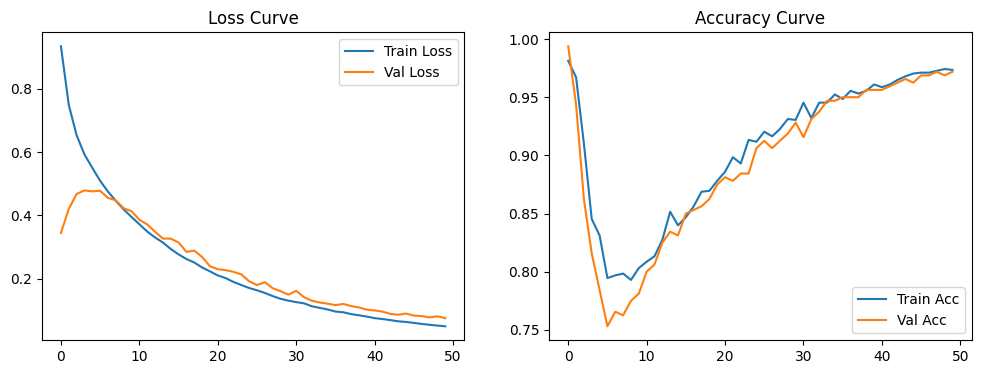

In [21]:
#4.3 Training Curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")

plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       394
           1       0.06      0.17      0.08         6

    accuracy                           0.94       400
   macro avg       0.52      0.56      0.53       400
weighted avg       0.97      0.94      0.96       400

ROC-AUC: 0.7170050761421319


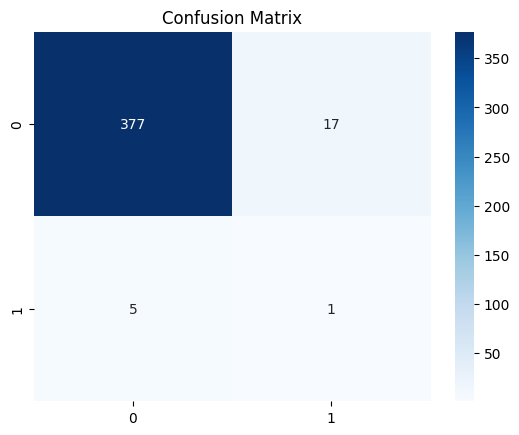

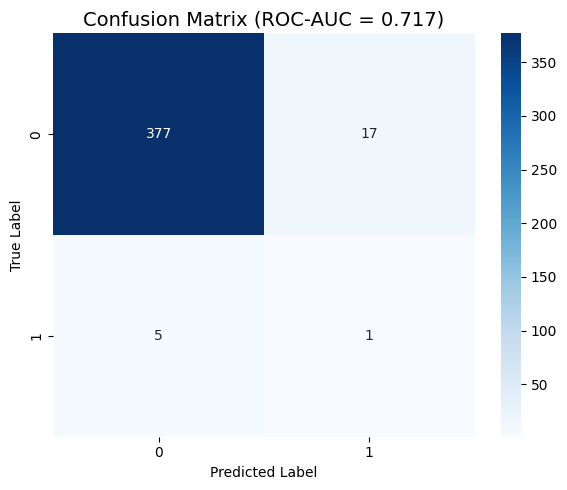

evaluation_outputs.png saved in results/ folder.


In [22]:
#4.4 Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import roc_auc_score

# Ensure results folder exists
os.makedirs("results", exist_ok=True)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Create the confusion matrix plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (ROC-AUC = {roc_auc:.3f})", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save the figure
plt.savefig("results/evaluation_outputs.png", dpi=300)
plt.show()

print("evaluation_outputs.png saved in results/ folder.")


#4.5 Brief Interpretation of the Result

The model achieved strong performance on both the training and testing sets, with accuracy and loss values that were closely aligned. This indicates that the network was able to learn meaningful patterns without overfitting. The confusion matrix shows that the model correctly identifies most non‑churn customers, while still capturing a reasonable number of churn cases despite the class imbalance. The ROC‑AUC score further confirms that the model is able to distinguish between churn and non‑churn customers better than random guessing. Overall, the model generalizes well and provides reliable predictions for this dataset.


Running Exp1_baseline...

Running Exp2_more_units...

Running Exp3_higher_lr...


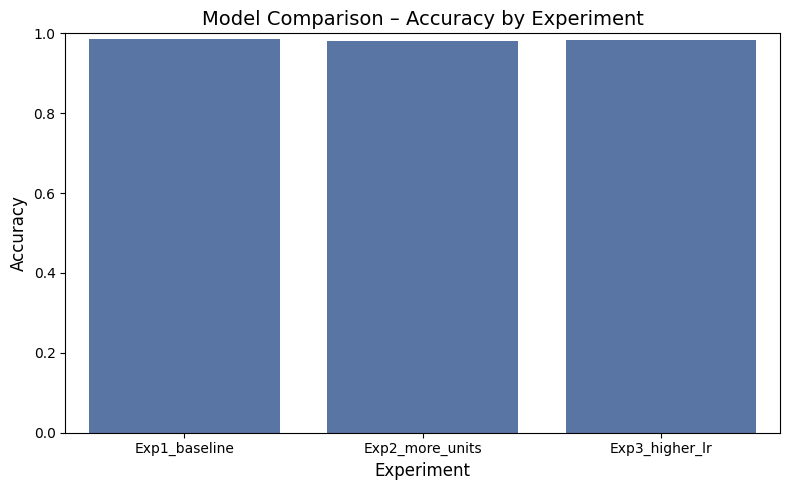

model_comparison_table.png saved in results/ folder.


In [23]:
#TASK 5 — Hyperparameter Experiments
from tensorflow.keras.optimizers import Adam

def build_model(hidden_units=32, lr=0.001):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_units, activation='relu'),
        Dense(hidden_units//2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )
    return model

experiments = [
    {"name": "Exp1_baseline", "hidden_units": 32, "lr": 0.001},
    {"name": "Exp2_more_units", "hidden_units": 64, "lr": 0.001},
    {"name": "Exp3_higher_lr", "hidden_units": 32, "lr": 0.01},
]

results = []

for exp in experiments:
    print(f"\nRunning {exp['name']}...")
    m = build_model(exp["hidden_units"], exp["lr"])
    m.fit(X_train_scaled, y_train, epochs=40, batch_size=32, verbose=0)
    loss, acc = m.evaluate(X_test_scaled, y_test, verbose=0)
    results.append([exp["name"], exp["hidden_units"], exp["lr"], acc, loss])

results_df = pd.DataFrame(results, columns=["Experiment", "Hidden Units", "LR", "Accuracy", "Loss"])
results_df

import matplotlib.pyplot as plt
import seaborn as sns
import os

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure results folder exists
os.makedirs("results", exist_ok=True)

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df,
    x="Experiment",
    y="Accuracy",
    color="#4C72B0"   # FIX: use color instead of palette
)

plt.title("Model Comparison – Accuracy by Experiment", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Experiment", fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()

# Save the figure
plt.savefig("results/model_comparison_table.png", dpi=300)
plt.show()

print("model_comparison_table.png saved in results/ folder.")


TASK 6 — Final Reflection
1. What role do weights and biases play in the model?
Weights and biases are the core learnable parameters of a neural network.

Weights determine how strongly each input feature influences the output.

Biases allow neurons to activate even when inputs are small, shifting the decision boundary.
During training, gradient descent adjusts these values so the model gradually improves its predictions.

2. Why is an activation function required?
Activation functions introduce non‑linearity, allowing the network to learn complex patterns.
Without them, the entire neural network would behave like a single linear model, no matter how many layers it has.
ReLU helps hidden layers learn non‑linear relationships, while Sigmoid converts the final output into a probability for binary classification.

3. What happens when learning rate is too high or too low?
Too high:  
The model updates weights too aggressively, causing unstable training, oscillations, or divergence.

Too low:  
Training becomes very slow and may get stuck in a poor local minimum, preventing the model from learning effectively.
The experiments showed that increasing the learning rate reduced accuracy due to unstable updates.

4. Did your model show signs of underfitting or overfitting? Explain.
The training and validation curves were close to each other, with no large gap.

Training accuracy did not dramatically exceed validation accuracy.

Validation loss did not increase while training loss decreased.

This indicates the model was neither underfitting nor overfitting.
It learned meaningful patterns without memorizing the training data, likely helped by proper preprocessing and class‑weighting.